# Exercise 1: Advanced Agent Patterns with LangGraph

In this exercise, you will learn to:
1. Build a custom agent using LangGraph
2. Define state schemas
3. Create nodes and edges
4. Implement conditional routing
5. Add error handling
6. Implement human-in-the-loop approval

**Prerequisites**: Make sure you have completed Lecture 5 exercises and have your OpenAI API key configured.

## Setup

First, let's install the required packages and set up our environment.

In [3]:
# Install required packages
!pip install langchain langchain-openai langgraph tenacity --quiet


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

# Verify that the required environment variables are set
assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY is not set! Check your .env file."
assert os.environ.get("OPENAI_ENDPOINT"), "OPENAI_ENDPOINT is not set! Check your .env file."

print("Environment variables loaded successfully!")

Environment variables loaded successfully!


In [5]:
from typing import Annotated, TypedDict, Literal
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
import json

# Initialize the LLM
llm = ChatOpenAI(base_url=os.environ["OPENAI_ENDPOINT"], model="model-group3")

## Part 1: Understanding LangGraph State

In LangGraph, state is a TypedDict that flows through all nodes in your graph. Let's start by defining a simple state.

In [6]:
# Define the state schema
class SimpleState(TypedDict):
    """State for our simple agent."""
    # The add_messages annotation tells LangGraph to append new messages
    # rather than replacing the entire list
    messages: Annotated[list, add_messages]

# Let's see how add_messages works
from langgraph.graph.message import add_messages

# Simulating state updates
current_messages = [HumanMessage(content="Hello!")]
new_messages = [AIMessage(content="Hi there!")]

# add_messages appends rather than replaces
result = add_messages(current_messages, new_messages)
print("Combined messages:")
for msg in result:
    print(f"  {msg.__class__.__name__}: {msg.content}")

Combined messages:
  HumanMessage: Hello!
  AIMessage: Hi there!


## Part 2: Building Your First LangGraph Agent

Let's build a simple agent that can use tools.

In [8]:
# Define some tools for our agent
@tool
def get_weather(location: str) -> str:
    """Get the current weather for a location."""
    # Simulated weather data
    weather_data = {
        "new york": "Sunny, 72°F",
        "london": "Cloudy, 58°F",
        "tokyo": "Rainy, 65°F",
        "paris": "Partly cloudy, 68°F"
    }
    return weather_data.get(location.lower(), f"Weather data not available for {location}")

@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression. Example: '2 + 2' or '10 * 5'"""
    try:
        # Safe evaluation of mathematical expressions
        allowed_chars = set('0123456789+-*/().% ')
        if not all(c in allowed_chars for c in expression):
            return "Error: Invalid characters in expression"
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f"Error: {str(e)}"

# List of tools
tools = [get_weather, calculate]

# Bind tools to the LLM
llm_with_tools = llm.bind_tools(tools)

print("Tools defined:")
for t in tools:
    print(f"  - {t.name}: {t.description}")

Tools defined:
  - get_weather: Get the current weather for a location.
  - calculate: Evaluate a mathematical expression. Example: '2 + 2' or '10 * 5'


In [9]:
# Define the agent node - this is where the LLM decides what to do
def agent_node(state: SimpleState) -> dict:
    """The agent node calls the LLM to decide the next action."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# Define the routing function
def should_continue(state: SimpleState) -> Literal["tools", "end"]:
    """Determine whether to continue to tools or end."""
    messages = state["messages"]
    last_message = messages[-1]
    
    # If the LLM made tool calls, route to tools
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    
    # Otherwise, we're done
    return "end"

In [10]:
# Build the graph
graph = StateGraph(SimpleState)

# Add nodes
graph.add_node("agent", agent_node)
graph.add_node("tools", ToolNode(tools))  # ToolNode is a prebuilt node for executing tools

# Add edges
graph.add_edge(START, "agent")  # Start with the agent
graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",  # If tools, go to tools node
        "end": END  # If end, finish
    }
)
graph.add_edge("tools", "agent")  # After tools, go back to agent

# Compile the graph
app = graph.compile()

print("Graph compiled successfully!")

Graph compiled successfully!


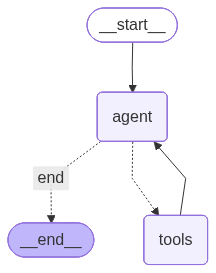

In [10]:
# Visualize the graph (optional - requires additional dependencies)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization not available. Graph structure:")
    print(app.get_graph().draw_ascii())

In [11]:
# Test the agent!
def run_agent(query: str):
    """Run the agent with a query and display the results."""
    print(f"\n{'='*50}")
    print(f"Query: {query}")
    print('='*50)
    
    result = app.invoke({"messages": [HumanMessage(content=query)]})
    
    print("\nConversation:")
    for msg in result["messages"]:
        if isinstance(msg, HumanMessage):
            print(f"\n👤 Human: {msg.content}")
        elif isinstance(msg, AIMessage):
            if msg.tool_calls:
                print(f"\n🤖 AI: [Calling tools: {[tc['name'] for tc in msg.tool_calls]}]")
            else:
                print(f"\n🤖 AI: {msg.content}")
        elif isinstance(msg, ToolMessage):
            print(f"\n🔧 Tool ({msg.name}): {msg.content}")
    
    return result

# Test with different queries
run_agent("What's the weather in Tokyo?")


Query: What's the weather in Tokyo?

Conversation:

👤 Human: What's the weather in Tokyo?

🤖 AI: [Calling tools: ['get_weather']]

🔧 Tool (get_weather): Rainy, 65°F

🤖 AI: The weather in Tokyo is **rainy** and **65°F**.


{'messages': [HumanMessage(content="What's the weather in Tokyo?", additional_kwargs={}, response_metadata={}, id='30d6e2c6-3c34-4a85-b450-d8e30c71bcf4'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 165, 'total_tokens': 183, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DZwJ21npMrnZ4a1EvBCsODGutSprH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd8c0-610e-7710-a516-7fae1a0a2988-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Tokyo'}, 'id': 'call_9mJyc8U3ZAV0LTtxponl37jk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 165, 'output_tok

In [12]:
# Test with a calculation
run_agent("What is 15% of 230?")


Query: What is 15% of 230?

Conversation:

👤 Human: What is 15% of 230?

🤖 AI: [Calling tools: ['calculate']]

🔧 Tool (calculate): 34.5

🤖 AI: 15% of 230 is **34.5**.


{'messages': [HumanMessage(content='What is 15% of 230?', additional_kwargs={}, response_metadata={}, id='5f5ecec7-cbf7-4877-8b74-7caed0cf82ad'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 168, 'total_tokens': 190, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DZwJC0K46O29gOejcuAEwbkqu26q9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd8c0-88f8-7913-91cb-bcd6810306bf-0', tool_calls=[{'name': 'calculate', 'args': {'expression': '0.15 * 230'}, 'id': 'call_7GaBfvveySIQ0nVwRNOrwQqD', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 168, 'output_tokens'

In [13]:
# Test with multiple tools
run_agent("What's the weather in London? Also, calculate 72 - 58.")


Query: What's the weather in London? Also, calculate 72 - 58.

Conversation:

👤 Human: What's the weather in London? Also, calculate 72 - 58.

🤖 AI: [Calling tools: ['get_weather', 'calculate']]

🔧 Tool (get_weather): Cloudy, 58°F

🔧 Tool (calculate): 14

🤖 AI: London: Cloudy, 58°F  
72 - 58 = 14


{'messages': [HumanMessage(content="What's the weather in London? Also, calculate 72 - 58.", additional_kwargs={}, response_metadata={}, id='f6bf4923-d0f2-4b1e-955d-5054366cf872'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 174, 'total_tokens': 224, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DZwJHYW0YP3MGGFJVhFjnedArrIR6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd8c0-9e60-7160-849e-995a43141767-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'London'}, 'id': 'call_DoSFighbAcMmtJukteIMQumG', 'type': 'tool_call'}, {'name': 'calculate', 'args': {'expression': 

## Part 3: Adding More Complex State

Let's enhance our state to track more information.

In [14]:
# Enhanced state with additional tracking
class EnhancedState(TypedDict):
    messages: Annotated[list, add_messages]
    iteration_count: int
    tools_used: list[str]
    status: str

def enhanced_agent_node(state: EnhancedState) -> dict:
    """Enhanced agent that tracks iterations."""
    messages = state["messages"]
    iteration = state.get("iteration_count", 0) + 1
    
    # Add system message about iteration
    if iteration > 5:
        # Prevent infinite loops
        return {
            "messages": [AIMessage(content="I've reached the maximum number of iterations. Here's what I found so far.")],
            "status": "max_iterations_reached",
            "iteration_count": iteration
        }
    
    response = llm_with_tools.invoke(messages)
    
    # Track which tools were called
    tools_used = state.get("tools_used", [])
    if hasattr(response, 'tool_calls') and response.tool_calls:
        tools_used = tools_used + [tc['name'] for tc in response.tool_calls]
    
    return {
        "messages": [response],
        "iteration_count": iteration,
        "tools_used": tools_used,
        "status": "in_progress"
    }

def enhanced_should_continue(state: EnhancedState) -> Literal["tools", "end"]:
    """Check if we should continue or end."""
    # Check for max iterations
    if state.get("status") == "max_iterations_reached":
        return "end"
    
    messages = state["messages"]
    last_message = messages[-1]
    
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    
    return "end"

# Build enhanced graph
enhanced_graph = StateGraph(EnhancedState)
enhanced_graph.add_node("agent", enhanced_agent_node)
enhanced_graph.add_node("tools", ToolNode(tools))
enhanced_graph.add_edge(START, "agent")
enhanced_graph.add_conditional_edges("agent", enhanced_should_continue, {"tools": "tools", "end": END})
enhanced_graph.add_edge("tools", "agent")

enhanced_app = enhanced_graph.compile()
print("Enhanced graph compiled!")

Enhanced graph compiled!


In [15]:
# Test enhanced agent
result = enhanced_app.invoke({
    "messages": [HumanMessage(content="What's the weather in Paris and New York? Then calculate the temperature difference.")],
    "iteration_count": 0,
    "tools_used": [],
    "status": "starting"
})

print(f"\n📊 Agent Statistics:")
print(f"   Iterations: {result['iteration_count']}")
print(f"   Tools used: {result['tools_used']}")
print(f"   Final status: {result['status']}")
print(f"\n🤖 Final response: {result['messages'][-1].content}")


📊 Agent Statistics:
   Iterations: 3
   Tools used: ['get_weather', 'get_weather', 'calculate']
   Final status: in_progress

🤖 Final response: Paris: Partly cloudy, 68°F  
New York: Sunny, 72°F  

Temperature difference: **4°F**


## Part 4: Error Handling with Retry Logic

Let's add error handling using the `tenacity` library.

In [16]:
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
import random

# Simulate an unreliable API
@tool
def unreliable_search(query: str) -> str:
    """Search for information. This API is sometimes unreliable."""
    # Simulate random failures (30% failure rate)
    if random.random() < 0.3:
        raise Exception("API temporarily unavailable")
    return f"Search results for '{query}': Found relevant information about {query}."

# Wrap the tool with retry logic
@retry(
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=1, min=1, max=4),
    retry=retry_if_exception_type(Exception)
)
def search_with_retry(query: str) -> str:
    """Search with automatic retry on failure."""
    return unreliable_search.invoke(query)

# Test the retry logic
print("Testing unreliable search with retry:")
for i in range(5):
    try:
        result = search_with_retry("LangGraph tutorial")
        print(f"  Attempt {i+1}: Success - {result[:50]}...")
    except Exception as e:
        print(f"  Attempt {i+1}: Failed after retries - {e}")

Testing unreliable search with retry:
  Attempt 1: Success - Search results for 'LangGraph tutorial': Found rel...
  Attempt 2: Success - Search results for 'LangGraph tutorial': Found rel...
  Attempt 3: Success - Search results for 'LangGraph tutorial': Found rel...
  Attempt 4: Success - Search results for 'LangGraph tutorial': Found rel...
  Attempt 5: Success - Search results for 'LangGraph tutorial': Found rel...


## Part 5: Human-in-the-Loop

Let's add human approval before executing sensitive actions.

In [17]:
# Define a "sensitive" tool that requires approval
@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email to a recipient. This is a sensitive action."""
    return f"Email sent to {to} with subject '{subject}'"

# State with approval tracking
class ApprovalState(TypedDict):
    messages: Annotated[list, add_messages]
    pending_action: dict | None
    approved: bool

# Tools for this example
approval_tools = [get_weather, send_email]
llm_with_approval_tools = llm.bind_tools(approval_tools)

def approval_agent_node(state: ApprovalState) -> dict:
    """Agent that checks for sensitive actions."""
    messages = state["messages"]
    response = llm_with_approval_tools.invoke(messages)
    
    # Check if the response includes a sensitive tool call
    if hasattr(response, 'tool_calls') and response.tool_calls:
        for tc in response.tool_calls:
            if tc['name'] == 'send_email':
                # This is sensitive - needs approval
                return {
                    "messages": [response],
                    "pending_action": tc,
                    "approved": False
                }
    
    return {
        "messages": [response],
        "pending_action": None,
        "approved": True
    }

def check_approval(state: ApprovalState) -> Literal["tools", "await_approval", "end"]:
    """Route based on whether approval is needed."""
    if state.get("pending_action") and not state.get("approved"):
        return "await_approval"
    
    messages = state["messages"]
    last_message = messages[-1]
    
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    
    return "end"

def approval_node(state: ApprovalState) -> dict:
    """Node that handles approval requests."""
    pending = state["pending_action"]
    print(f"\n⚠️  APPROVAL REQUIRED ⚠️")
    print(f"   Action: {pending['name']}")
    print(f"   Arguments: {json.dumps(pending['args'], indent=2)}")
    
    # In a real application, this would wait for user input
    # For this exercise, we'll simulate approval
    user_input = input("   Approve? (yes/no): ").strip().lower()
    approved = user_input == "yes"
    
    if approved:
        print("   ✅ Approved!")
        return {"approved": True}
    else:
        print("   ❌ Rejected!")
        return {
            "messages": [AIMessage(content="The action was not approved by the user.")],
            "pending_action": None,
            "approved": False
        }

In [18]:
# Build graph with approval
approval_graph = StateGraph(ApprovalState)

approval_graph.add_node("agent", approval_agent_node)
approval_graph.add_node("tools", ToolNode(approval_tools))
approval_graph.add_node("await_approval", approval_node)

approval_graph.add_edge(START, "agent")
approval_graph.add_conditional_edges(
    "agent",
    check_approval,
    {
        "tools": "tools",
        "await_approval": "await_approval",
        "end": END
    }
)
approval_graph.add_edge("tools", "agent")
approval_graph.add_conditional_edges(
    "await_approval",
    lambda s: "tools" if s.get("approved") else "end",
    {"tools": "tools", "end": END}
)

approval_app = approval_graph.compile()
print("Approval graph compiled!")

Approval graph compiled!


In [19]:
# Test with a non-sensitive action (no approval needed)
print("Test 1: Non-sensitive action")
result = approval_app.invoke({
    "messages": [HumanMessage(content="What's the weather in London?")],
    "pending_action": None,
    "approved": True
})
print(f"\n🤖 Response: {result['messages'][-1].content}")

Test 1: Non-sensitive action

🤖 Response: London weather: Cloudy, 58°F.


In [ ]:
# Test with a sensitive action (approval needed)
print("\nTest 2: Sensitive action (type 'yes' or 'no' when prompted)")
result = approval_app.invoke({
    "messages": [HumanMessage(content="Send an email to alice@example.com with subject 'Meeting' and body 'Let's meet tomorrow.'")],
    "pending_action": None,
    "approved": True
})
print(f"\n🤖 Response: {result['messages'][-1].content}")


Test 2: Sensitive action (type 'yes' or 'no' when prompted)

⚠️  APPROVAL REQUIRED ⚠️
   Action: send_email
   Arguments: {
  "to": "alice@example.com",
  "subject": "Meeting",
  "body": "Let's meet tomorrow."
}


## 🎯 Challenge Exercises

Now it's your turn! Complete the following challenges:

### Challenge 1: Add a New Tool

Add a `get_time` tool that returns the current time for a given timezone.

In [20]:
# TODO: Implement the get_time tool
from datetime import datetime
from zoneinfo import ZoneInfo

# mapping common abbreviations to IANA timezones
TZ_MAP = {
    "UTC": "UTC",
    "GMT": "Etc/GMT",
    "EST": "America/New_York",    # Eastern Standard/Daylight (US)
    "EDT": "America/New_York",
    "CST": "America/Chicago",
    "CDT": "America/Chicago",
    "MST": "America/Denver",
    "MDT": "America/Denver",
    "PST": "America/Los_Angeles",
    "PDT": "America/Los_Angeles",
    "JST": "Asia/Tokyo",
    "AEST": "Australia/Sydney",
    "ACST": "Australia/Adelaide",
    "IST": "Asia/Kolkata",
}

def normalize_tz(tz: str) -> str:
    tz = tz.strip()
    # If exact IANA zone provided, return it
    if "/" in tz or tz.upper() == "UTC":
        return tz
    return TZ_MAP.get(tz.upper(), tz)

@tool
def get_time(tz: str) -> str:
    """Get the current time for a timezone. Examples: 'UTC', 'EST', 'PST', 'JST'"""
    try:
        zone = normalize_tz(tz)
        dt = datetime.now(ZoneInfo(zone))
        # ISO-like output with offset, e.g. "2026-04-29 15:42:10 -07:00 (PDT)"
        offset = dt.strftime("%z")
        offset = f"{offset[:3]}:{offset[3:]}" if offset else ""
        abbrev = dt.tzname() or ""
        return dt.strftime(f"%Y-%m-%d %H:%M:%S {offset} ({abbrev})")
    except Exception as e:
        return f"Error: could not resolve timezone '{tz}': {e}"

# Test your tool
print(get_time.invoke("UTC"))

2026-04-29 10:40:15 +00:00 (UTC)


### Challenge 2: Add Timeout Handling

Modify the agent to timeout if it takes too long to complete.

In [21]:
# TODO: Create an agent with timeout handling
# Hint: Track the start time in state and check elapsed time in the routing function

import time

class TimeoutState(TypedDict):
    messages: Annotated[list, add_messages]
    start_time: float
    max_seconds: int
    timeout_exceeded: bool

def timeout_agent_node(state: TimeoutState) -> dict:
    """Agent node that checks timeout before invoking LLM."""
    elapsed = time.time() - state["start_time"]
    
    if elapsed > state["max_seconds"]:
        return {
            "messages": [AIMessage(content="⏱️ Timeout exceeded. Agent execution stopped.")],
            "timeout_exceeded": True
        }
    
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    
    return {
        "messages": [response],
        "timeout_exceeded": False
    }

def timeout_should_continue(state: TimeoutState) -> Literal["tools", "end"]:
    """Route based on timeout and tool calls."""
    if state.get("timeout_exceeded"):
        return "end"
    
    elapsed = time.time() - state["start_time"]
    if elapsed > state["max_seconds"]:
        return "end"
    
    messages = state["messages"]
    last_message = messages[-1]
    
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    
    return "end"

# Build timeout graph
timeout_graph = StateGraph(TimeoutState)
timeout_graph.add_node("agent", timeout_agent_node)
timeout_graph.add_node("tools", ToolNode(tools))
timeout_graph.add_edge(START, "agent")
timeout_graph.add_conditional_edges("agent", timeout_should_continue, {"tools": "tools", "end": END})
timeout_graph.add_edge("tools", "agent")

timeout_app = timeout_graph.compile()
print("Timeout-aware graph compiled!")

# Test with a timeout
print("\nTesting with 5-second timeout:")
result = timeout_app.invoke({
    "messages": [HumanMessage(content="What's the weather in London?")],
    "start_time": time.time(),
    "max_seconds": 5,
    "timeout_exceeded": False
})
print(f"Final message: {result['messages'][-1].content}")
print(f"Timeout exceeded: {result['timeout_exceeded']}")

Timeout-aware graph compiled!

Testing with 5-second timeout:
Final message: Weather in London: Cloudy, 58°F.
Timeout exceeded: False


### Challenge 3: Multi-Step Approval

Create an agent that requires different approval levels for different actions (e.g., low-risk, medium-risk, high-risk).

In [ ]:
# TODO: Implement multi-level approval
# Define tools with different risk levels
# Route to different approval nodes based on risk

# Define tools with different risk levels
@tool
def read_file(filename: str) -> str:
    """Read a file (LOW RISK). Example: 'config.txt'"""
    return f"Contents of {filename}: [simulated file contents]"

@tool
def send_message(recipient: str, message: str) -> str:
    """Send a message to a user (MEDIUM RISK)."""
    return f"Message sent to {recipient}: '{message}'"

@tool
def delete_file(filename: str) -> str:
    """Delete a file from the system (HIGH RISK). Cannot be undone!"""
    return f"File '{filename}' has been permanently deleted."

@tool
def modify_settings(setting: str, value: str) -> str:
    """Modify system settings (HIGH RISK). May affect system stability."""
    return f"Setting '{setting}' changed to '{value}'."

# Map tools to risk levels
TOOL_RISK_LEVELS = {
    "read_file": "low",
    "send_message": "medium",
    "delete_file": "high",
    "modify_settings": "high"
}

# State for multi-level approval
class MultiApprovalState(TypedDict):
    messages: Annotated[list, add_messages]
    pending_action: dict | None
    risk_level: str  # "low", "medium", "high"
    approved: bool

# Tools for multi-level approval
multi_tools = [read_file, send_message, delete_file, modify_settings]
llm_with_multi_tools = llm.bind_tools(multi_tools)

def get_tool_risk_level(tool_name: str) -> str:
    """Determine the risk level of a tool."""
    return TOOL_RISK_LEVELS.get(tool_name, "low")

def multi_approval_agent_node(state: MultiApprovalState) -> dict:
    """Agent that identifies tool risk levels."""
    messages = state["messages"]
    response = llm_with_multi_tools.invoke(messages)
    
    # Check if the response includes tool calls and determine risk level
    if hasattr(response, 'tool_calls') and response.tool_calls:
        # Get the highest risk level among all tool calls
        max_risk = "low"
        risk_order = {"low": 0, "medium": 1, "high": 2}
        
        for tc in response.tool_calls:
            tool_risk = get_tool_risk_level(tc['name'])
            if risk_order[tool_risk] > risk_order[max_risk]:
                max_risk = tool_risk
        
        # If any tool is medium or high risk, require approval
        if max_risk in ["medium", "high"]:
            return {
                "messages": [response],
                "pending_action": response.tool_calls[0],
                "risk_level": max_risk,
                "approved": False
            }
    
    return {
        "messages": [response],
        "pending_action": None,
        "risk_level": "low",
        "approved": True
    }

def check_multi_approval(state: MultiApprovalState) -> Literal["tools", "low_approval", "medium_approval", "high_approval", "end"]:
    """Route based on risk level."""
    if state.get("pending_action") and not state.get("approved"):
        risk = state["risk_level"]
        if risk == "low":
            return "low_approval"
        elif risk == "medium":
            return "medium_approval"
        else:
            return "high_approval"
    
    messages = state["messages"]
    last_message = messages[-1]
    
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    
    return "end"

def low_approval_node(state: MultiApprovalState) -> dict:
    """Low-risk approval - automatic approval."""
    pending = state["pending_action"]
    print(f"\n✅ LOW RISK ACTION (Auto-approved)")
    print(f"   Tool: {pending['name']}")
    print(f"   Arguments: {json.dumps(pending['args'], indent=2)}")
    return {"approved": True}

def medium_approval_node(state: MultiApprovalState) -> dict:
    """Medium-risk approval - requires user confirmation."""
    pending = state["pending_action"]
    print(f"\n⚠️  MEDIUM RISK ACTION (User confirmation required)")
    print(f"   Tool: {pending['name']}")
    print(f"   Arguments: {json.dumps(pending['args'], indent=2)}")
    
    user_input = input("   Proceed? (yes/no): ").strip().lower()
    approved = user_input == "yes"
    
    if approved:
        print("   ✅ Approved!")
        return {"approved": True}
    else:
        print("   ❌ Rejected!")
        return {
            "messages": [AIMessage(content="The action was rejected by the user.")],
            "pending_action": None,
            "approved": False
        }

def high_approval_node(state: MultiApprovalState) -> dict:
    """High-risk approval - requires explicit user confirmation."""
    pending = state["pending_action"]
    print(f"\n🚨 HIGH RISK ACTION (Explicit confirmation required)")
    print(f"   Tool: {pending['name']}")
    print(f"   Arguments: {json.dumps(pending['args'], indent=2)}")
    print(f"\n   ⚠️  WARNING: This action cannot be undone!")
    
    user_input = input("   Type 'CONFIRM' to proceed, or 'CANCEL' to reject: ").strip().upper()
    approved = user_input == "CONFIRM"
    
    if approved:
        print("   ✅ Action confirmed and executed!")
        return {"approved": True}
    else:
        print("   ❌ Action cancelled by user!")
        return {
            "messages": [AIMessage(content="The high-risk action was cancelled by the user.")],
            "pending_action": None,
            "approved": False
        }

# Build multi-level approval graph
multi_approval_graph = StateGraph(MultiApprovalState)

multi_approval_graph.add_node("agent", multi_approval_agent_node)
multi_approval_graph.add_node("tools", ToolNode(multi_tools))
multi_approval_graph.add_node("low_approval", low_approval_node)
multi_approval_graph.add_node("medium_approval", medium_approval_node)
multi_approval_graph.add_node("high_approval", high_approval_node)

multi_approval_graph.add_edge(START, "agent")
multi_approval_graph.add_conditional_edges(
    "agent",
    check_multi_approval,
    {
        "tools": "tools",
        "low_approval": "low_approval",
        "medium_approval": "medium_approval",
        "high_approval": "high_approval",
        "end": END
    }
)
multi_approval_graph.add_edge("tools", "agent")

# After any approval node, go to tools if approved
for approval_node_name in ["low_approval", "medium_approval", "high_approval"]:
    multi_approval_graph.add_conditional_edges(
        approval_node_name,
        lambda s: "tools" if s.get("approved") else "end",
        {"tools": "tools", "end": END}
    )

multi_approval_app = multi_approval_graph.compile()
print("Multi-level approval graph compiled!")

# Test cases
print("\n" + "="*60)
print("Test 1: Low-risk action (should auto-approve)")
print("="*60)
result = multi_approval_app.invoke({
    "messages": [HumanMessage(content="Read the config.txt file for me")],
    "pending_action": None,
    "risk_level": "low",
    "approved": True
})
print(f"\nFinal response: {result['messages'][-1].content if isinstance(result['messages'][-1], (AIMessage, ToolMessage)) else 'Action completed'}")

print("\n" + "="*60)
print("Test 2: Medium-risk action (requires user confirmation)")
print("="*60)
result = multi_approval_app.invoke({
    "messages": [HumanMessage(content="Send a message to John saying hello")],
    "pending_action": None,
    "risk_level": "low",
    "approved": True
})
print(f"\nFinal response: {result['messages'][-1].content if isinstance(result['messages'][-1], (AIMessage, ToolMessage)) else 'Action completed'}")

print("\n" + "="*60)
print("Test 3: High-risk action (requires explicit confirmation)")
print("="*60)
result = multi_approval_app.invoke({
    "messages": [HumanMessage(content="Delete the old_backup.tar.gz file")],
    "pending_action": None,
    "risk_level": "low",
    "approved": True
})
print(f"\nFinal response: {result['messages'][-1].content if isinstance(result['messages'][-1], (AIMessage, ToolMessage)) else 'Action completed'}")

Multi-level approval graph compiled!

Test 1: Low-risk action (should auto-approve)

Final response: Here’s the contents of `config.txt`:

`[simulated file contents]`

Test 2: Medium-risk action (requires user confirmation)

⚠️  MEDIUM RISK ACTION (User confirmation required)
   Tool: send_message
   Arguments: {
  "recipient": "John",
  "message": "hello"
}


## Summary

In this exercise, you learned:

1. **State Management**: How to define and use TypedDict state schemas with annotations
2. **Graph Building**: Creating nodes, edges, and conditional routing
3. **Tool Integration**: Binding tools to LLMs and executing them
4. **Error Handling**: Using retry logic for unreliable operations
5. **Human-in-the-Loop**: Adding approval workflows for sensitive actions

These patterns form the foundation for building robust, production-ready agents!